<a href="https://colab.research.google.com/github/Heptazero/data-mining/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 下载

In [11]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric -q
from torch_geometric.datasets import EllipticBitcoinDataset

dataset = EllipticBitcoinDataset(root='/content/drive/MyDrive/data-mining/elliptic')
data = dataset[0]

print(data)
# 中文字体补丁：本地与 Colab 都使用 Python 标准库下载，不依赖 wget
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.font_manager as fm

_FONT_PATH = Path("NotoSansCJKtc-Regular.otf")
_FONT_URL = (
    "https://raw.githubusercontent.com/notofonts/noto-cjk/main/"
    "Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
)
if not _FONT_PATH.exists():
    try:
        urlretrieve(_FONT_URL, _FONT_PATH)
    except OSError as error:
        print(f"中文字体下载失败：{error}")
if _FONT_PATH.exists():
    fm.fontManager.addfont(_FONT_PATH)
    plt.rcParams["font.family"] = "Noto Sans CJK TC"
plt.rcParams["axes.unicode_minus"] = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], test_mask=[203769])


## 展示
- 一个节点就是一笔比特币交易，每笔交易身上挂着165个数字
  - 前94个叫"本地特征"，是这笔交易自己的信息——发生在49个时间步里的第几步、这笔交易有几个输入几个输出、手续费多少、总输出金额多少，还有一些跟它直接相连的输入输出的平均值
  - 剩下72个叫"聚合特征"，是这笔交易周围一圈邻居交易的统计值——邻居们的最大值、最小值、标准差、相关系数。
  - 每一项数值："这一项比平均水平高还是低"

In [3]:
import pandas as pd

feature_df = pd.DataFrame(data.x.numpy())
print("节点数、特征数：", feature_df.shape)
feature_df.head()

节点数、特征数： (203769, 165)


,0,1,2,3,4,5,6,7,8,9,...,155,156,157,158,159,160,161,162,163,164
0,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782743,12.414557,-0.163645,-0.115831,0.043598,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,0.041399,0.935886,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


- 每一列是一条边
- 上面那行是边的起点，下面那行是边的终点。

In [8]:
print("边的数量：", data.edge_index.shape[1])
data.edge_index[:, :5]

边的数量： 234355


tensor([[0, 2, 4, 6, 8],
        [1, 3, 5, 7, 9]])

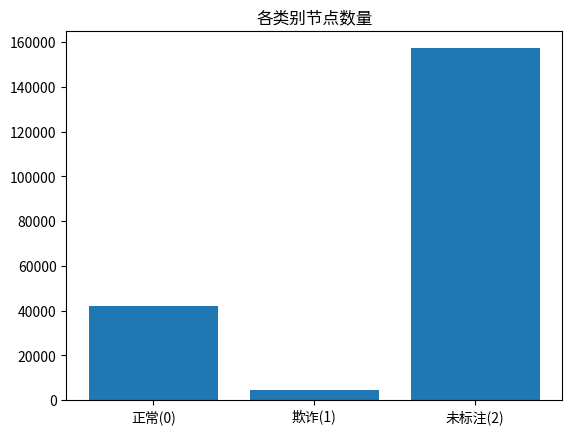

In [12]:
import matplotlib.pyplot as plt

names = ['正常(0)', '欺诈(1)', '未标注(2)']
plt.bar(names, counts.tolist())
plt.title('各类别节点数量')
plt.show()

- 原始论文里每个时间段大概跨两周，49个时间段前后连起来大概覆盖了近三年的比特币交易记录。

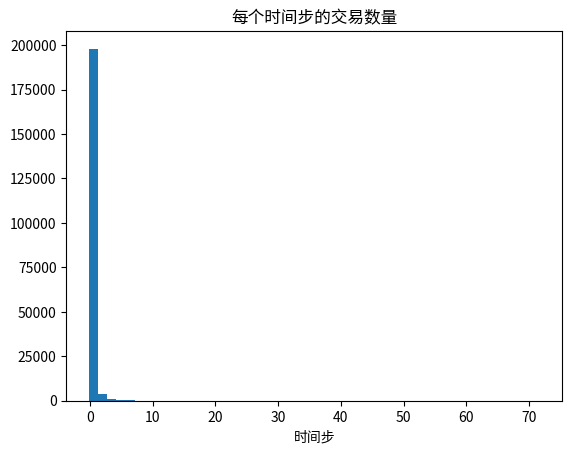

In [13]:

import torch
time_steps = data.x[:, 0]
plt.hist(time_steps.numpy(), bins=49)
plt.title('每个时间步的交易数量')
plt.xlabel('时间步')
plt.show()

In [14]:
print("特征里有没有缺失值：", torch.isnan(data.x).any().item())

特征里有没有缺失值： False
